<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/04_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Imports
2. Dataset paths/settings
3. Load datasets
4. Prefetch
5. Load EfficientNetB0
6. Build 5-class model
7. Check model
8. Compile
9. Callbacks
10. Train
11. Learning curves
12. Test evaluation
13. Classification report
14. Confusion matrix

Step 1 — Imports

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

Step 2 — Dataset paths and settings

In [2]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "casino",
    "warehouse",
    "inside_subway"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the datasets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2500 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.


In [4]:
#Verify
print("Class names:", train_ds.class_names)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(test_ds).numpy()
)

Class names: ['kitchen', 'bedroom', 'casino', 'warehouse', 'inside_subway']
Training batches: 79
Validation batches: 14
Test batches: 14


Step 4 — Prefetch

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset prefetching configured.")

Dataset prefetching configured.


Step 5 — Load the pretrained EfficientNetB0

In [7]:
base_model = EfficientNetB0(
    include_top=False, # Removes the original ImageNet classification head
    weights="imagenet", #oads features learned from the ImageNet dataset.
    input_shape=(224, 224, 3)
)

base_model.trainable = False # Freezes the pretrained EfficientNetB0 weights

print("EfficientNetB0 loaded successfully.")
print("Base model trainable:", base_model.trainable) #initially freezes EfficientNetB0 so its pretrained features are not changed

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully.
Base model trainable: False


Step 6 — Build the 5-class classification model

In [8]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False) #Extracts features using pretrained EfficientNetB0

x = tf.keras.layers.GlobalAveragePooling2D()(x) #Converts feature maps into a compact feature vector

x = tf.keras.layers.Dropout(0.2)(x) #Helps reduce overfitting

outputs = tf.keras.layers.Dense(
    5,                      #Produces predictions for our 5 selected classes
    activation="softmax"   #Converts outputs into class probabilities
)(x)

model = tf.keras.Model(inputs, outputs)

print("EfficientNetB0 model created successfully.")

EfficientNetB0 model created successfully.


Step 7 — Check the model

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Step 8 — Compile the model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), #it expects integer class labels rather than one-hot encoded labels.
    metrics=["accuracy"]
)

In [11]:
print("Model compiled successfully.")

Model compiled successfully.


Step 9 — Set up training callbacks
1.   EarlyStopping — stops training if validation loss stops improving.
2.   ModelCheckpoint — saves the best version of the model.



In [12]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/efficientnetb0_balanced500_best.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 10 — Train EfficientNetB0

In [13]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.8716 - loss: 0.4943 - val_accuracy: 0.9791 - val_loss: 0.1400
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.9728 - loss: 0.1177 - val_accuracy: 0.9814 - val_loss: 0.0921
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.9804 - loss: 0.0839 - val_accuracy: 0.9791 - val_loss: 0.0752
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9848 - loss: 0.0666 - val_accuracy: 0.9791 - val_loss: 0.0668
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.9892 - loss: 0.0552 - val_accuracy: 0.9791 - val_loss: 0.0629
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.9888 - loss: 0.0453 - val_accuracy: 0.9791 - val_loss: 0.0574
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.9908 - loss: 0.0410 - val_accuracy: 0.9791 - val_loss: 0.0545
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.9920 - loss: 0.0352 - val_accuracy: 0.9791 - v

Step 11 - Plot the learning curves

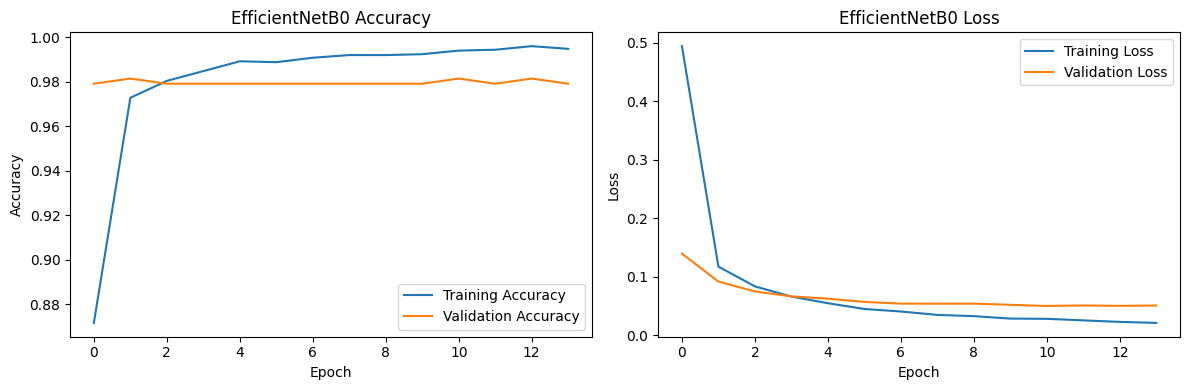

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 12 - Test evaluation

In [15]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.9839 - loss: 0.0492
Test Loss: 0.04918138310313225
Test Accuracy: 0.9838709831237793


Step 13 - Classification Report

In [16]:
import numpy as np
from sklearn.metrics import classification_report

# Get the true labels from the test dataset
y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

# Get model predictions
y_prob = model.predict(test_ds)

# Convert probabilities to predicted class numbers
y_pred = np.argmax(y_prob, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step
               precision    recall  f1-score   support

      kitchen       0.97      0.97      0.97       111
      bedroom       0.97      0.97      0.97       100
       casino       1.00      0.99      0.99        78
    warehouse       0.99      1.00      0.99        76
inside_subway       1.00      1.00      1.00        69

     accuracy                           0.98       434
    macro avg       0.99      0.99      0.99       434
 weighted avg       0.98      0.98      0.98       434



Step 14 — Confusion Matrix

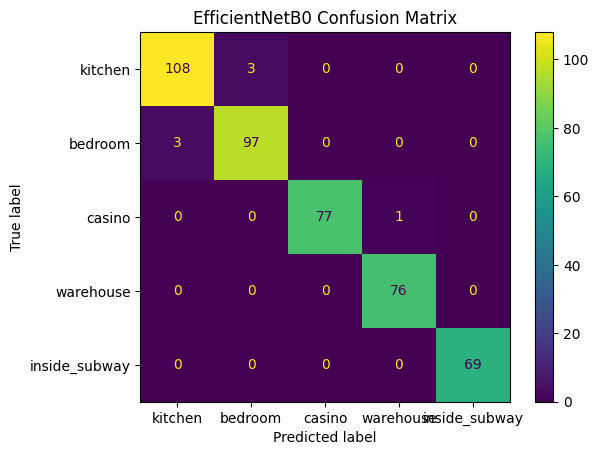

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()